# 05 — Detection Dataset Preparation (Milestone 2)

Walks from the raw CelebA identity crops (Milestone 1's individual + class-pool
identities) through synthetic multi-celebrity grid composition, YOLO-format
bounding box annotation, a documented augmentation strategy, and a leak-free
train/val/test split — the exact dataset Milestone 3 will fine-tune YOLOv8 on.

Run this after `data/` (CelebA files) is in place, same as Milestone 1.


## 1. Class-wide identity pool

Milestone 1 had each of us individually claim one CelebA identity. Priyanka's
Milestone 2 instructions require each 3x3 grid to use **9 unique identities
drawn from the whole class pool** (not just our own team's 4), so we pull in
the identities every group's members claimed, from the shared class
spreadsheet.

In [1]:
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    """Search upward from the current directory for the project root
    (identified by having both a src/ and a notebooks/ folder), so this
    works whether Jupyter's working directory is the notebooks/ folder,
    the project root, or anything in between."""
    p = start.resolve()
    for candidate in [p] + list(p.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError(
        f"Could not find the project root (a folder containing both src/ and "
        f"notebooks/) starting from {start}. Make sure this notebook lives "
        f"inside the project's notebooks/ folder."
    )

REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "src"))
print("REPO_ROOT:", REPO_ROOT)

import pandas as pd

# The class-wide identity pool (from the shared Google Sheet), name -> (group, celeb_id)
CLASS_POOL = [
    ("Dario Garza", 1, 797), ("Yosephine Tong", 1, 10002), ("Murat Akca", 1, 5695),
    ("Abdellah Faleh", 2, 3), ("Samuel Tong", 2, 1212), ("Jin-woo Hong", 2, 7), ("Tristan Lyons", 2, 8335),
    ("Julia Rasmussen", 3, 4422), ("Rhea Paul", 3, 2970), ("Mus Ab Irfan Yilmaz", 3, 7007), ("Masato Kan", 3, 2336),
    ("David Fung", 4, 4428),
    ("Jiasong Zhang", 5, 2619),
]
pool_df = pd.DataFrame(CLASS_POOL, columns=["name", "group", "celeb_id"])
pool_df


REPO_ROOT: C:\Users\abdel\Desktop\7615\project1_celeba\project1_celeba


,name,group,celeb_id
0,Dario Garza,1,797
1,Yosephine Tong,1,10002
2,Murat Akca,1,5695
3,Abdellah Faleh,2,3
4,Samuel Tong,2,1212
5,Jin-woo Hong,2,7
6,Tristan Lyons,2,8335
7,Julia Rasmussen,3,4422
8,Rhea Paul,3,2970
9,Mus Ab Irfan Yilmaz,3,7007


## 2. Extract face crops for every identity in the pool

Reuses the same extraction logic as Milestone 1 (`extract_identity_images.py`),
generalized to a list of IDs in `extract_class_pool_images.py`, so every
identity's crops end up in `extracted_identities/<id>/` ready for grid
composition.

In [2]:
from extract_class_pool_images import extract_one
import pandas as pd

identity_path = REPO_ROOT / "data" / "identity_CelebA.txt"
assert identity_path.exists(), "Missing data/identity_CelebA.txt — set up data/ as in Milestone 1."

identity_df = pd.read_csv(identity_path, sep=r"\s+", header=None, names=["image_id", "identity"])

pool_ids = pool_df["celeb_id"].tolist()
for iid in pool_ids:
    n = extract_one(identity_df, iid)
    print(f"  id={iid:>6}  images_available={n}")


  id=   797  images_available=25
  id= 10002  images_available=23
  id=  5695  images_available=25
  id=     3  images_available=25
  id=  1212  images_available=25
  id=     7  images_available=24
  id=  8335  images_available=25
  id=  4422  images_available=25
  id=  2970  images_available=25
  id=  7007  images_available=24
  id=  2336  images_available=25
  id=  4428  images_available=23
  id=  2619  images_available=25


## 3. Compose synthetic multi-celebrity 3x3 grids

Each grid places 9 unique identities (drawn from the pool above, including our
own team's 4) into a 3x3 layout, resized to 640x640 for YOLOv8. Placement,
scale, and background are randomized per grid so no two grids repeat the same
arrangement — 6 grids total: 2 for this report, 4 additional ones for
Priyanka's cross-group aggregation for Milestone 3.

In [3]:
from build_synthetic_detection_dataset import compose_grid, draw_preview
import random, json

unique_ids = sorted(set(pool_ids))
class_map = {iid: idx for idx, iid in enumerate(unique_ids)}

DATASET_DIR = REPO_ROOT / "detection_dataset"
IMAGES_DIR, LABELS_DIR, PREVIEW_DIR = DATASET_DIR / "images", DATASET_DIR / "labels", DATASET_DIR / "previews"
for d in (IMAGES_DIR, LABELS_DIR, PREVIEW_DIR):
    d.mkdir(parents=True, exist_ok=True)
(DATASET_DIR / "classes.json").write_text(json.dumps(class_map, indent=2))

N_GRIDS = 6
grids_made = []
used_arrangements = set()
for grid_idx in range(1, N_GRIDS + 1):
    rng = random.Random(42 + grid_idx)
    for _ in range(50):
        chosen = rng.sample(unique_ids, 9)
        if tuple(chosen) not in used_arrangements:
            used_arrangements.add(tuple(chosen))
            break
    canvas, label_rows = compose_grid(chosen, class_map, rng)
    name = f"grid_{grid_idx:04d}"
    canvas.save(IMAGES_DIR / f"{name}.jpg", quality=95)
    with open(LABELS_DIR / f"{name}.txt", "w") as f:
        for class_id, xc, yc, w, h, _, _ in label_rows:
            f.write(f"{class_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")
    draw_preview(canvas, label_rows).save(PREVIEW_DIR / f"{name}_preview.jpg", quality=90)
    grids_made.append((name, chosen))
    print(f"Wrote {name}: identities={chosen}")


Wrote grid_0001: identities=[3, 2336, 797, 4422, 2619, 7, 1212, 8335, 2970]
Wrote grid_0002: identities=[2970, 4428, 8335, 7, 797, 10002, 5695, 7007, 3]
Wrote grid_0003: identities=[2336, 2970, 4422, 10002, 7, 5695, 797, 3, 2619]
Wrote grid_0004: identities=[7, 2970, 3, 5695, 1212, 797, 2336, 8335, 7007]
Wrote grid_0005: identities=[2619, 7, 2970, 4428, 4422, 10002, 797, 2336, 1212]
Wrote grid_0006: identities=[4428, 2619, 797, 10002, 5695, 2336, 2970, 4422, 7]


### Sample annotated grids (inline verification)

Rendering two of the composed grids with bounding boxes drawn on top, to
visually confirm every face has a tight, correctly localized box.

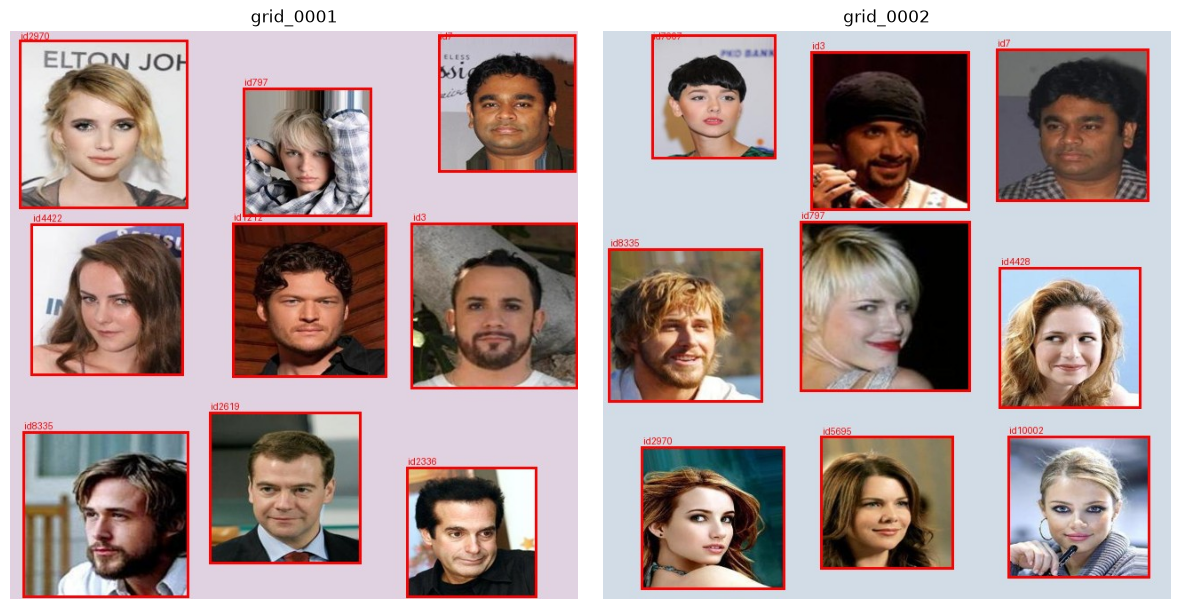

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, (name, _) in zip(axes, grids_made[:2]):
    img = Image.open(PREVIEW_DIR / f"{name}_preview.jpg")
    ax.imshow(img)
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 4. Augmentation strategy

Applied to every grid to increase effective dataset diversity for detection
training. Each transform is bounded so every face stays inside the 640x640
frame, and bounding boxes are mathematically recomputed to match:

| Augmentation | Parameters | Why |
|---|---|---|
| Horizontal flip | p = 0.5 | Faces are roughly left-right symmetric — free extra viewpoint diversity, label-safe (just mirrors x-coordinates) |
| Bounded rotation | ±8° | Simulates a slightly tilted camera/photo; boxes recomputed as the axis-aligned bound of the rotated face corners |
| Brightness jitter | 0.85x – 1.15x | Simulates different lighting across "shared backgrounds"; does not affect box coordinates |
| Contrast jitter | 0.85x – 1.15x | Same rationale as brightness; pixel-only change |
| Centered zoom | 0.95x – 1.05x | Simulates minor camera distance/framing differences; boxes rescaled around the image center to match |

Boxes are clipped to the frame and dropped only if less than 10% of their
original area would remain visible (does not occur in practice at these
bounded parameters for a centered 3x3 grid).

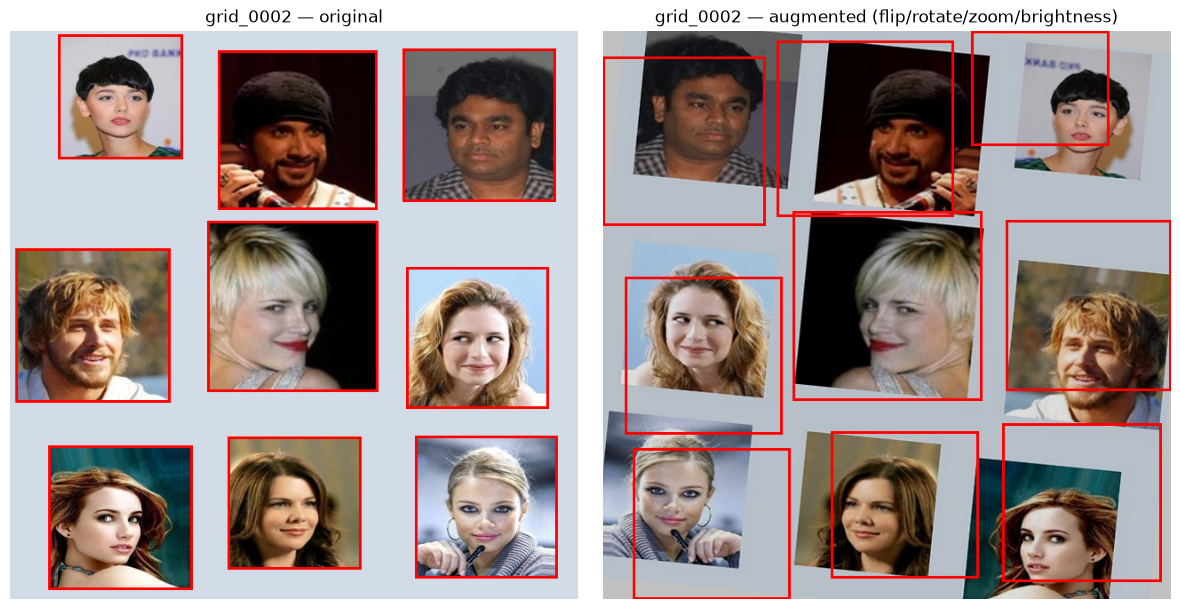

In [5]:
from augment_and_split_detection_dataset import augment_one, read_yolo_labels
import random

sample_name, _ = grids_made[1]
sample_image = Image.open(IMAGES_DIR / f"{sample_name}.jpg").convert("RGB")
sample_rows = read_yolo_labels(LABELS_DIR / f"{sample_name}.txt")

aug_image, aug_rows = augment_one(sample_image, sample_rows, random.Random(7))

from PIL import ImageDraw

def draw_boxes(img, rows):
    img = img.copy()
    draw = ImageDraw.Draw(img)
    W, H = img.size
    for cls, xc, yc, w, h in rows:
        x0, y0, x1, y1 = (xc-w/2)*W, (yc-h/2)*H, (xc+w/2)*W, (yc+h/2)*H
        draw.rectangle([x0, y0, x1, y1], outline=(255,0,0), width=3)
    return img

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(draw_boxes(sample_image, sample_rows)); axes[0].set_title(f"{sample_name} — original"); axes[0].axis("off")
axes[1].imshow(draw_boxes(aug_image, aug_rows)); axes[1].set_title(f"{sample_name} — augmented (flip/rotate/zoom/brightness)"); axes[1].axis("off")
plt.tight_layout()
plt.show()


## 5. Train / validation / test split

Split at the **base grid** level (not per augmented copy), so every augmented
version of a given grid lands in the same split — this is what prevents image
leakage across train/val/test. Default: 4 grids -> train, 1 -> val, 1 -> test,
each grid producing 1 original + 4 augmented copies.

In [6]:
import subprocess, sys as _sys

result = subprocess.run(
    [_sys.executable, str(REPO_ROOT / "src" / "augment_and_split_detection_dataset.py"), "--n-aug", "4"],
    capture_output=True, text=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)


Split (by base grid, no leakage):
  train: base grids = ['grid_0004', 'grid_0002', 'grid_0003', 'grid_0005']
  val: base grids = ['grid_0001']
  test: base grids = ['grid_0006']

Total images written (original + augmented copies): train=20, val=5, test=5
Manifest written to C:\Users\abdel\Desktop\7615\project1_celeba\project1_celeba\detection_dataset\split_manifest.csv



In [7]:
split_manifest = pd.read_csv(DATASET_DIR / "split_manifest.csv")
display(split_manifest.groupby("split")["output_name"].count().rename("n_images"))

# sanity check: no base grid appears in more than one split (no leakage)
leak_check = split_manifest.groupby("base_grid")["split"].nunique()
assert (leak_check == 1).all(), "Leakage detected: a base grid appears in multiple splits!"
print("No leakage confirmed: every base grid's images are entirely within one split.")
split_manifest.head(10)


split
test      5
train    20
val       5
Name: n_images, dtype: int64

No leakage confirmed: every base grid's images are entirely within one split.


,base_grid,output_name,split,augmentation,n_boxes
0,grid_0001,grid_0001_orig,val,none,9
1,grid_0001,grid_0001_aug1,val,aug1,9
2,grid_0001,grid_0001_aug2,val,aug2,9
3,grid_0001,grid_0001_aug3,val,aug3,9
4,grid_0001,grid_0001_aug4,val,aug4,9
5,grid_0002,grid_0002_orig,train,none,9
6,grid_0002,grid_0002_aug1,train,aug1,9
7,grid_0002,grid_0002_aug2,train,aug2,9
8,grid_0002,grid_0002_aug3,train,aug3,9
9,grid_0002,grid_0002_aug4,train,aug4,9


## 6. Summary

- **6 base grid images** (640x640, 3x3 layout, 9 unique class-pool identities each)
- **Augmentation:** horizontal flip (p=0.5), ±8° rotation, brightness/contrast jitter (0.85x-1.15x), centered zoom (0.95x-1.05x) — 4 augmented copies + 1 original per base grid
- **Split:** 4 base grids -> train (20 images), 1 -> val (5 images), 1 -> test (5 images); no image leakage across splits
- **Dataset location:** `detection_dataset/{train,val,test}/{images,labels}/`, `classes.json` (identity_id -> class_id mapping), `split_manifest.csv` (full provenance)
- **Next step (Milestone 3):** fine-tune YOLOv8 directly on `detection_dataset/{train,val,test}/`
